In [ ]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [ ]:
fake["label"] = 0
true["label"] = 1

In [ ]:
df = pd.concat([fake, true])

df = df.sample(frac=1)

df.head()

,title,text,subject,date,label
19770,Vietnam finds misconduct in city that will hos...,HANOI (Reuters) - Vietnam s ruling party watch...,worldnews,"September 18, 2017",1
18217,U.S. poised to lift sanctions on Sudan: official,WASHINGTON (Reuters) - The United States is pr...,worldnews,"October 5, 2017",1
17071,Former soccer star Kaladze runs for mayor in G...,TBILISI (Reuters) - Kakha Kaladze climbed to t...,worldnews,"October 19, 2017",1
1203,Trump Declares That America ‘Worships God’ An...,Donald Trump shredded the First Amendment duri...,News,"June 9, 2017",0
8448,FBI expects Clinton documents will not be rele...,WASHINGTON (Reuters) - The FBI said Tuesday it...,politicsNews,"August 16, 2016",1


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 19770 to 3294
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


,0
title,0
text,0
subject,0
date,0
label,0


### Feature Engineering
To prepare the text data for machine learning models, we'll combine the 'title' and 'text' columns into a single 'content' column. This will give us a unified text field to extract features from.

In [ ]:
# Combine 'title' and 'text' into a new 'content' column
df['content'] = df['title'] + ' ' + df['text']

# Display the first few rows with the new 'content' column
display(df[['title', 'text', 'content']].head())

,title,text,content
19770,Vietnam finds misconduct in city that will hos...,HANOI (Reuters) - Vietnam s ruling party watch...,Vietnam finds misconduct in city that will hos...
18217,U.S. poised to lift sanctions on Sudan: official,WASHINGTON (Reuters) - The United States is pr...,U.S. poised to lift sanctions on Sudan: offici...
17071,Former soccer star Kaladze runs for mayor in G...,TBILISI (Reuters) - Kakha Kaladze climbed to t...,Former soccer star Kaladze runs for mayor in G...
1203,Trump Declares That America ‘Worships God’ An...,Donald Trump shredded the First Amendment duri...,Trump Declares That America ‘Worships God’ An...
8448,FBI expects Clinton documents will not be rele...,WASHINGTON (Reuters) - The FBI said Tuesday it...,FBI expects Clinton documents will not be rele...


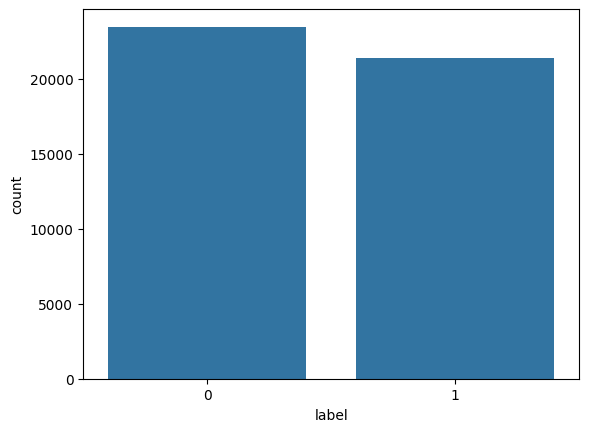

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="label", data=df)

plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

### Text Vectorization
We will use `TfidfVectorizer` to convert the text content into numerical features. TF-IDF (Term Frequency-Inverse Document Frequency) is a numerical statistic that is intended to reflect how important a word is to a document in a collection or corpus.

In [ ]:
# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

# Fit and transform the 'content' column
X = tfidf_vectorizer.fit_transform(df['content'])

# Get the target variable (labels)
y = df['label']

print(f"Shape of feature matrix (X): {X.shape}")
print(f"Shape of target vector (y): {y.shape}")

Shape of feature matrix (X): (44898, 122200)
Shape of target vector (y): (44898,)


### Data Splitting
Now, we'll split the data into training and testing sets. This allows us to train our models on one portion of the data and evaluate their performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (35918, 122200)
Shape of X_test: (8980, 122200)
Shape of y_train: (35918,)
Shape of y_test: (8980,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

In [ ]:
from sklearn.model_selection import train_test_split

X = df["text"]      # or your TF-IDF features
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X = vectorizer.fit_transform(df['text'])
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

lr = LogisticRegression()
lr.fit(X_train, y_train)

nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [ ]:
from sklearn.metrics import accuracy_score

#logistic regression prediction
lr_pred = lr.predict(X_test)

#naive bayes prediction
nb_pred = nb.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Logistic Regression Accuracy: 0.9819599109131403
Naive Bayes Accuracy: 0.929510022271715


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report:")
print(classification_report(y_test, lr_pred))

print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, nb_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4681
           1       0.98      0.98      0.98      4299

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980


Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4681
           1       0.93      0.92      0.93      4299

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, lr_pred))

[[4589   92]
 [  70 4229]]


In [ ]:
news = """
India launched a new AI-Powered education initiative to
improve outcomes across schools."""

news_vector =  vectorizer.transform([news])

prediction = lr.predict(news_vector)

if prediction[0] == 1:
    print("Real News")
else:
    print("Fake News")

Fake News


In [ ]:
import pickle

pickle.dump(lr, open("fake_news_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
sample = df.iloc[0]["content"]

sample_vector = vectorizer.transform([sample])

prediction = lr.predict(sample_vector)

print(prediction)

[1]


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 94.4 MB/s eta 0:00:00


In [ ]:
import pickle

model = pickle.load(open("fake_news_model.pkl", "rb"))

print(type(model))


<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [ ]:
vectorizer = pickle.load(open("vectorizer.pkl", "rb"))

print(type(vectorizer))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [ ]:
app_code = '''
import streamlit as st
import pickle

model = pickle.load(open("fake_news_model.pkl", "rb"))
vectorizer = pickle.load(open("vectorizer.pkl", "rb"))

st.title("Fake News Detection App")

news = st.text_area("Enter News Text")

if st.button("Predict"):
    news_vector = vectorizer.transform([news])
    prediction = model.predict(news_vector)

    if prediction[0] == 1:
        st.success("Real News")
    else:
        st.error("Fake News")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [28]:
requirements = '''
streamlit
scikit-learn
pandas
numpy
'''

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!
